The problem with Convolution
- Memory Issue
- Translation Variance

1. Memory Issue:  
Take this example -   
A single image have shape 228x228x3,  
Lets have 100 filters of shape 3x3, 
We will have hundered feature maps with shape = 226x226   
When we merge them, we will have a single output of shape = (226x226)x100

If each pixel is stored in 32bit size, then   
Output of single image will take space = 226x226x100x32 = 20MB storage   
If we take a batch of even 100 images, we will need 2 GB storage


This can be solved by using strides, and Pooling

In [5]:
226*226*100*32/(8 * 1000 * 1000)

20.4304

2. Translation Variance   
The features of an object should not be location dependent right? I mean, it should not matter if an ear of a cat is at right side of image or left side of the image, its an ear of a cat and we need to identify it regardless of the position in image.   

_Translation variance is a disability of a model, where it becomes dependent on location to identify any feature_

We want _Translation invariance_ in our model

This is solved by Pooling

## Pooling
- Pooling is a down sampling operation i.e It reduces size of feature map
- It is applied after convolution operation
- We add non-linearity to feature map before pooling - ex: Relu, i.e We apply relu function on each pixel of feature map
- There are many types of pooling operation 
    - Max Pooling
    - Avg Pooling
    - Global Pooling
        - Global Max Pooling
        - Global Min Pooling

How it works:   
We select three parameters: Size, Stride, Type (Generally Size = (2,2), Stride = 2, Type = Max)   
Now, From original feature map, we move a sliding window, and take max/min/avg pixel (according to type of pooling) in the current window.   
And get a new Feature map with lesser size

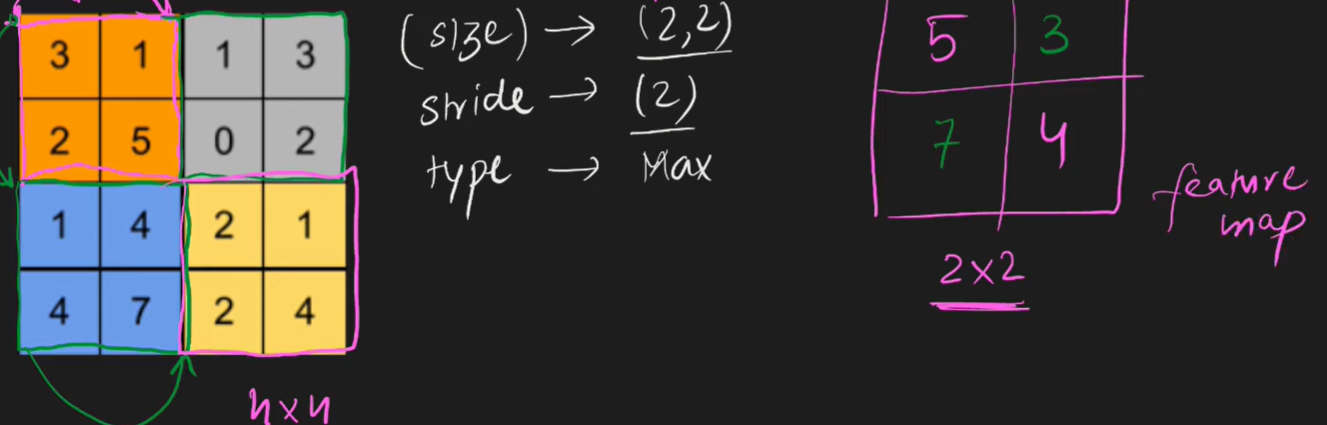

How its eleminating Translation variance?   
In max pooling, in each small region (receptive field), the algorithm is only keeping the most dominant feature, and low level features gets eliminated    
This is how we down sample the feature map and get Translation invariance

- There are many types of pooling operation 
    - Max Pooling: We keep max pixel from each receptive field
    - Avg Pooling: We calculate avg of all pixels in the receptive field and keep it 
    - Global Pooling
        - Global Max Pooling: We take one max value from each feature map 
        - Global Avg Pooling: We take avg of all pixels in the feature map for all feature maps

        ex: If there are 32 filters in conv layer, then the output will have 32 layered feature map, if we apply global pooling, then we will get 32 values (one from each layer)

[Visualization of Pooling by deeplizard.com](https://deeplizard.com/resource/pavq7noze3)

In [18]:
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten #We are using images with 2 channels hence, MaxPooling2D
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [20]:
model = Sequential()
model.add(Input(shape = (28,28,1)))

model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation = 'softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

### Advantages of Pooling
1. Reduces size
2. Gives Translation Invariance to model, how? See the image below, those are two same images with slight position difference, but still image after poolinig is same 
3. Max Pooling Enhances Features, because it only takes the most imp pixel from each area. see the image below for example
4. No need of training. Pooling does not have any trainable parameters, its just an aggregation function

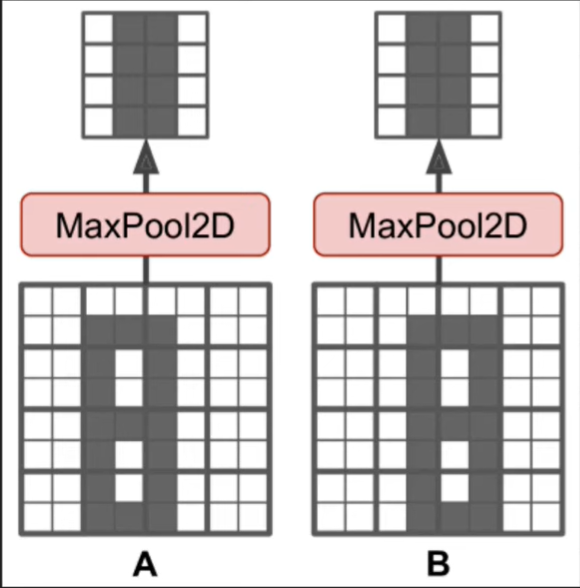

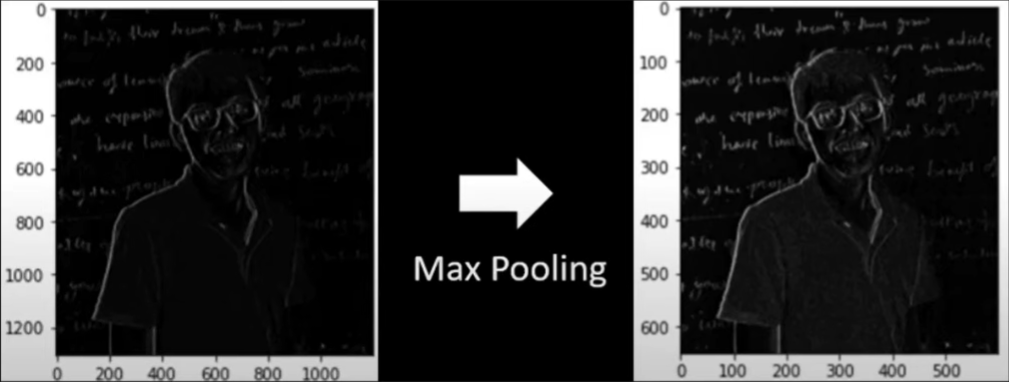

### Disadvantages 
1. There are some situations where we do not want Translation Invariance. Ex: Image segmentation or cases where location of object is important to identify
2. It loses a lot of information 